In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from scipy.stats import lognorm

In [44]:
# Specify the parameters of the distrubtion
alpha         = 0.9898277902846392
beta          = 1.0416318444260435
std_residuals = 0.36253906130541547
c             = -1.8758112050799398

In [45]:
# Specify the maximal acceptable error
max_acceptable_error = 0.030714285714285715 # Value found in the paper, can be changed by the user
max_acceptable_error = 0.03

# Case one: existing application

We will consider how to study the maximal error in the case that an Expected Threat model is already in use. To illustrate this, we will use the situation of the Expected Threat model by Karun Singh (2018) in hist blog post.<br>
In this example we have $M=192$ and $N=620,000$.

In [46]:
# Number of states/squares in the model
M = 192

# Number of training data points
N = 620_000 

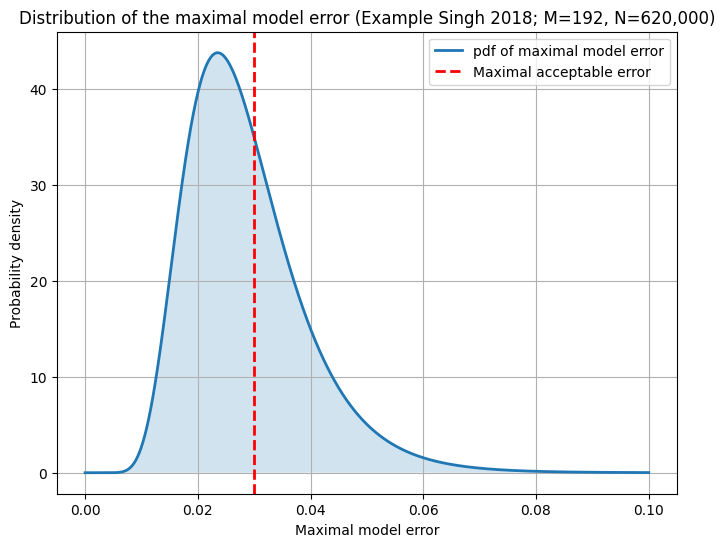

In [47]:
# Plot the distribution
plt.figure(figsize=(8, 6))
x = np.linspace(0, 0.1, 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
plt.plot(x, y, lw=2, label='pdf of maximal model error')
plt.axvline(max_acceptable_error, color='red', linestyle='--', lw=2, label='Maximal acceptable error')
plt.fill_between(x, y, alpha=0.2)

plt.xlabel('Maximal model error')
plt.ylabel('Probability density')
plt.title(f'Distribution of the maximal model error (Example Singh 2018; M=192, N=620,000)')
plt.legend()
plt.grid()

plt.show()

In [48]:
prob_acceptable_error = lognorm.cdf(max_acceptable_error, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
print(f'Probability of acceptable error: {prob_acceptable_error:.4f}')

Probability of acceptable error: 0.6209


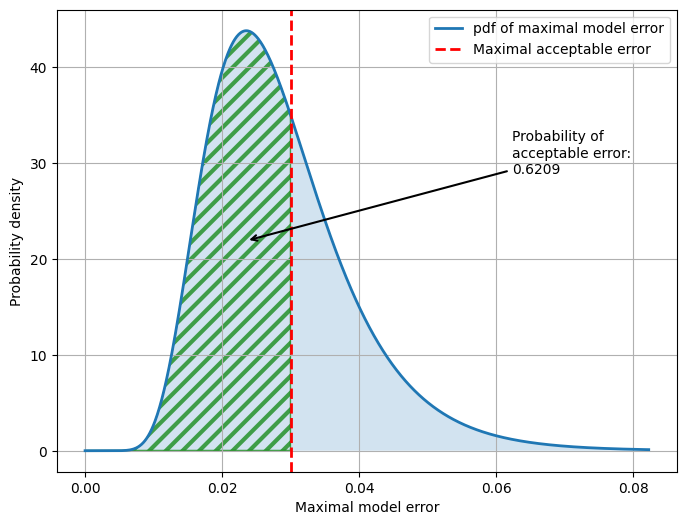

In [49]:
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 3.0

# Plot the distribution
plt.figure(figsize=(8, 6))

percentile_0999 = lognorm.ppf(0.999, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x = np.linspace(0, percentile_0999, 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
plt.plot(x, y, lw=2, label='pdf of maximal model error')

plt.fill_between(x, y, alpha=0.2)

plt.axvline(max_acceptable_error, color='red', linestyle='--', lw=2, label='Maximal acceptable error')

plt.fill_between(x, y, max_acceptable_error, 
                 where=(x < max_acceptable_error), 
                 alpha=0.7, 
                 facecolor='none', 
                 hatch='//',
                 edgecolor='green',    
                #  edgelinewidth=5,           
                 )


percentile_099 = lognorm.ppf(0.99, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
prob_acceptable_error = lognorm.cdf(max_acceptable_error, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x_ = min(x[np.argmax(y)], max_acceptable_error * 0.8)
y_ = lognorm.pdf(x_, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))/2
plt.annotate(f'Probability of\nacceptable error: \n{prob_acceptable_error:.4f}',
             xy=(x_, y_),
             xytext=(percentile_099, np.max(y)*0.66),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             )

plt.xlabel('Maximal model error')
plt.ylabel('Probability density')
# plt.title(f'Distribution of the maximal model error (Example Singh 2018; M=192, N=620,000)')
plt.legend()
plt.grid()

plt.show()

# Case two: Given a data set, find grid size

In [64]:
number_of_data_points = 2_480_000
# number_of_data_points = 3_000_000

desired_certainty = 0.9
# desired_certainty = 0.75 

# Specify the ratio between the number of discretization points in the x and y directions
nx_ny_ratio = 3/4

# Specify the minimal number of descretization points in the x-direction
min_nx = 6 # Corresponds to (6x5) grid
max_nx = 32 # Corresponds to (32x24) grid


In [67]:
nxs = np.arange(min_nx, max_nx+1)
nys = np.ceil(nx_ny_ratio*nxs).astype(int)

print([(int(nxs[i]), int(nys[i])) for i in range(len(nxs))])

Ms = nxs * nys

Ms = Ms[Ms < 500]

[(6, 5), (7, 6), (8, 6), (9, 7), (10, 8), (11, 9), (12, 9), (13, 10), (14, 11), (15, 12), (16, 12), (17, 13), (18, 14), (19, 15), (20, 15), (21, 16), (22, 17), (23, 18), (24, 18), (25, 19), (26, 20), (27, 21), (28, 21), (29, 22), (30, 23), (31, 24), (32, 24)]


Max M with acceptable error: 130
Corresponding nx: 13
Corresponding ny: 10


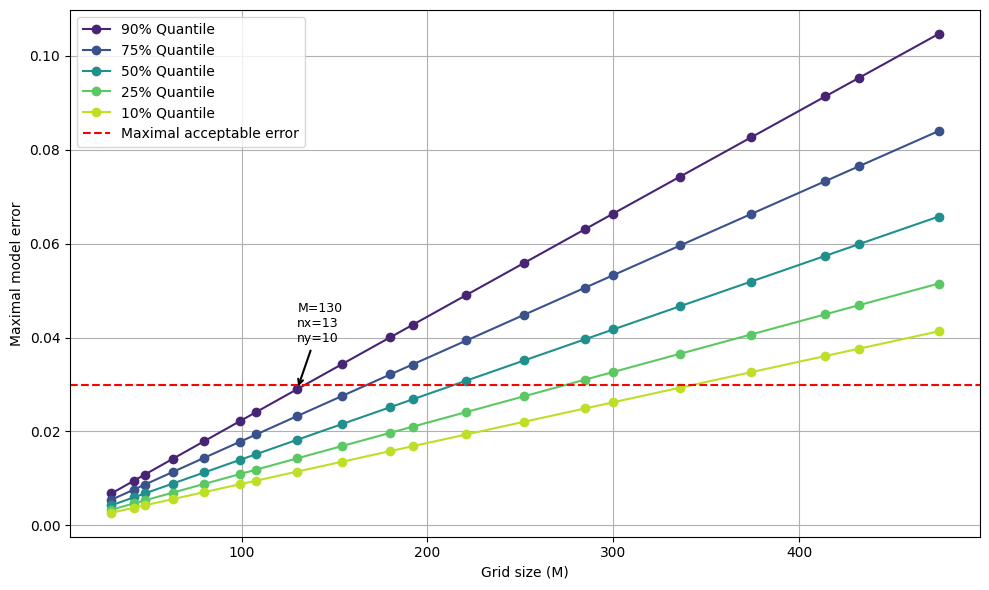

In [68]:
plt.figure(figsize=(10, 6))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
    plt.plot(Ms, qs, label=f'{int(q*100)}% Quantile', marker='o', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M with acceptable error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Annotate the largest M below max_max_error
plt.annotate(f'M={int(M)}\nnx={int(n_x)}\nny={int(n_y)}', xy=(M, qs[index]), xytext=(M, qs[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label='Maximal acceptable error')
plt.xlabel('Grid size (M)')
plt.ylabel('Maximal model error')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()


Max M with acceptable error: 130
Corresponding nx: 13
Corresponding ny: 10


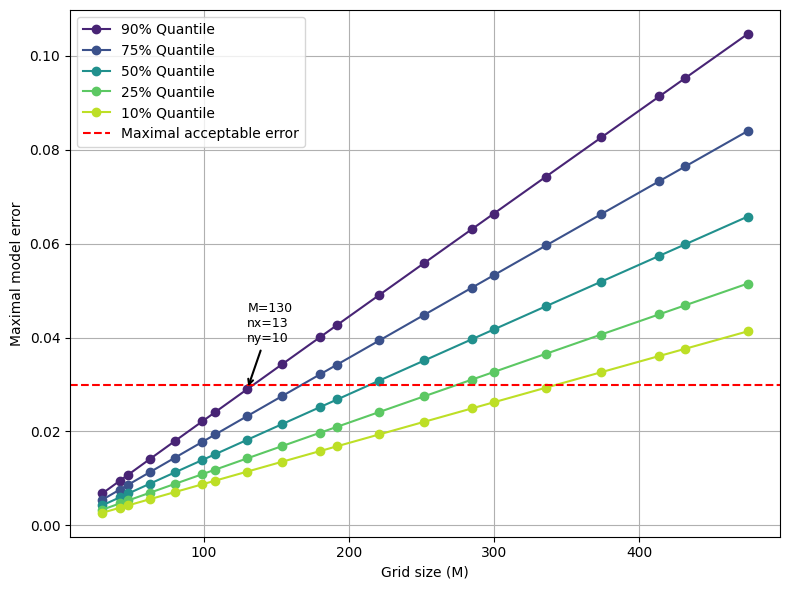

In [69]:
plt.figure(figsize=(8, 6))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
    plt.plot(Ms, qs, label=f'{int(q*100)}% Quantile', marker='o', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M with acceptable error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Annotate the largest M below max_max_error
plt.annotate(f'M={int(M)}\nnx={int(n_x)}\nny={int(n_y)}', xy=(M, qs[index]), xytext=(M, qs[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label='Maximal acceptable error')
plt.xlabel('Grid size (M)')
plt.ylabel('Maximal model error')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()


# Case three: Given a grid size, find data set size

In [41]:
# Specify desired grid
n_x = 24
n_y = 18

M = n_x * n_y
print(f"Grid size (M): {M}")

Ns = np.linspace(100_000, 10_000_000, 100)

Grid size (M): 432


Min N with acceptable error: [5800000.]


C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_20436\4046589668.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.annotate(f'N={int(N):,}', xy=(N, qs[index]), xytext=(N, qs[index]+0.01),


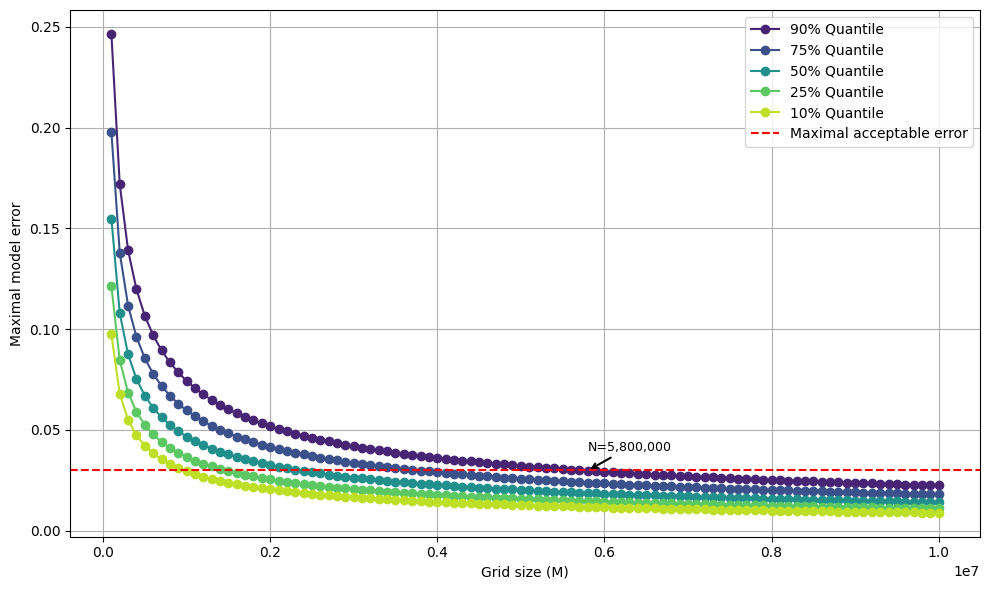

In [42]:
plt.figure(figsize=(10, 6))

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# Plot the quantiles
for q in quantiles:
    qs = lognorm.ppf(q, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns))))
    plt.plot(Ns, qs, label=f'{int(q*100)}% Quantile', marker='o', color=cm.viridis_r(q))

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[:-1][0]
# Get the corresponding M, nx, and ny values
N = Ns[index]
print(f"Min N with acceptable error: {N}")

# Annotate the largest M below max_max_error
plt.annotate(f'N={int(N):,}', xy=(N, qs[index]), xytext=(N, qs[index]+0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5), fontsize=9, color='black')

# Add horizontal line at max_max_error
plt.axhline(y=max_acceptable_error, color='red', linestyle='--', label='Maximal acceptable error')
plt.xlabel('Grid size (M)')
plt.ylabel('Maximal model error')
# plt.title('Quantiles of xT_error_inf_norm vs M')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.xscale('log')
# plt.xticks(Ms, rotation=90)
plt.show()
